# 11. Bayesian Personalised Ranking (BPR) on implicit interactions

## Purpose

This notebook implements a Bayesian Personalised Ranking (BPR) recommender on the chronological implicit interaction data.

BPR is a pairwise ranking model designed for implicit feedback settings. Rather than predicting ratings directly, it learns to rank observed user–item interactions above unobserved items. This makes it suitable for Top-N recommendation tasks on sparse implicit data.

This notebook builds on earlier phases:

- Phase 04 created modelling-ready datasets
- Phase 05 created chronological train / validation / test splits
- Phase 07 implemented the popularity baseline
- Phase 08 implemented neighbourhood collaborative filtering
- Phase 09 implemented truncated SVD matrix factorisation
- Phase 10 implemented the hybrid recommender

## Main tasks

- load chronological implicit train, validation, and test splits
- inspect train-fitted mapping coverage
- build train-only user positive-item histories
- train a BPR model on implicit interactions
- generate Top-N recommendations for mapped users
- exclude items already seen in training
- evaluate ranking quality on validation and test
- analyse catalogue coverage, novelty, and recommendation concentration
- save outputs for later comparison and dashboard use

In [2]:
from __future__ import annotations

import json
import math
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

## 1. Set project paths

Set project paths and create output subdirectories for the BPR phase.

In [3]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.paths import (
    SPLITS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    LOGS_DIR,
    SAVED_MODELS_DIR,
    ensure_directories,
)

MODEL_NAME = "bpr"
TOP_K_VALUES = [5, 10, 20]
EXPORT_TOP_N = 10

# Main tunable hyperparameters
N_FACTORS = 64
LEARNING_RATE = 0.05
REGULARIZATION = 0.0025
N_EPOCHS = 10
N_SAMPLES_PER_EPOCH = 300000
RANDOM_STATE = 42

TABLES_SUBDIR = TABLES_DIR / MODEL_NAME
FIGURES_SUBDIR = FIGURES_DIR / MODEL_NAME
LOGS_SUBDIR = LOGS_DIR / MODEL_NAME
MODELS_SUBDIR = SAVED_MODELS_DIR / MODEL_NAME

ensure_directories()
TABLES_SUBDIR.mkdir(parents=True, exist_ok=True)
FIGURES_SUBDIR.mkdir(parents=True, exist_ok=True)
LOGS_SUBDIR.mkdir(parents=True, exist_ok=True)
MODELS_SUBDIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Split directory:", SPLITS_DIR)
print("Tables output:", TABLES_SUBDIR)
print("Figures output:", FIGURES_SUBDIR)
print("Logs output:", LOGS_SUBDIR)
print("Models output:", MODELS_SUBDIR)

Project root: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project
Split directory: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits
Tables output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\bpr
Figures output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\figures\bpr
Logs output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\logs\bpr
Models output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\saved_models\bpr


## 2. Load implicit chronological splits

The BPR model is trained on the implicit interaction split because BPR is designed for implicit Top-N ranking tasks.
These splits were created in Phase 5 and already include train-fitted `user_idx` and `item_idx` columns.

In [4]:
train_path = SPLITS_DIR / "implicit_train.parquet"
valid_path = SPLITS_DIR / "implicit_valid.parquet"
test_path = SPLITS_DIR / "implicit_test.parquet"

for path in [train_path, valid_path, test_path]:
    print(path, "exists:", path.exists())

implicit_train = pd.read_parquet(train_path).copy()
implicit_valid = pd.read_parquet(valid_path).copy()
implicit_test = pd.read_parquet(test_path).copy()

print("Implicit train shape:", implicit_train.shape)
print("Implicit valid shape:", implicit_valid.shape)
print("Implicit test shape:", implicit_test.shape)

display(implicit_train.head(3))
display(implicit_valid.head(3))
display(implicit_test.head(3))

E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits\implicit_train.parquet exists: True
E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits\implicit_valid.parquet exists: True
E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits\implicit_test.parquet exists: True
Implicit train shape: (792656, 9)
Implicit valid shape: (169855, 9)
Implicit test shape: (169856, 9)


,user_id,recipe_id,date,rating,review_exists,is_unrated_observation,implicit_feedback,user_idx,item_idx
0,2008,992,2000-01-25,5,1,0,1,11,410
1,2008,3603,2000-01-25,4,1,0,1,11,1154
2,2046,517,2000-02-25,5,1,0,1,13,250


,user_id,recipe_id,date,rating,review_exists,is_unrated_observation,implicit_feedback,user_idx,item_idx
0,242205,55768,2010-06-17,5,1,0,1,27992.0,30765.0
1,242729,391308,2010-06-17,5,1,0,1,28058.0,NaN
2,254446,223104,2010-06-17,5,1,0,1,29303.0,118077.0


,user_id,recipe_id,date,rating,review_exists,is_unrated_observation,implicit_feedback,user_idx,item_idx
0,141284,15646,2012-12-28,5,1,0,1,16396.0,7048.0
1,155896,41728,2012-12-28,4,1,0,1,18012.0,22676.0
2,158966,121583,2012-12-28,5,1,0,1,18380.0,68592.0


## 3. Inspect required columns

Confirm that the split datasets contain the fields needed for BPR training and Top-N evaluation.

In [5]:
required_cols = [
    "user_id",
    "recipe_id",
    "date",
    "implicit_feedback",
    "user_idx",
    "item_idx",
]

for split_name, df in {
    "train": implicit_train,
    "valid": implicit_valid,
    "test": implicit_test,
}.items():
    missing = [c for c in required_cols if c not in df.columns]
    print(split_name, "missing columns:", missing)

print("Train columns:")
print(sorted(implicit_train.columns.tolist()))

train missing columns: []
valid missing columns: []
test missing columns: []
Train columns:
['date', 'implicit_feedback', 'is_unrated_observation', 'item_idx', 'rating', 'recipe_id', 'review_exists', 'user_id', 'user_idx']


In [6]:
for df in [implicit_train, implicit_valid, implicit_test]:
    df["date"] = pd.to_datetime(df["date"])

print("Train date range:", implicit_train["date"].min(), "to", implicit_train["date"].max())
print("Valid date range:", implicit_valid["date"].min(), "to", implicit_valid["date"].max())
print("Test date range:", implicit_test["date"].min(), "to", implicit_test["date"].max())

Train date range: 2000-01-25 00:00:00 to 2010-06-17 00:00:00
Valid date range: 2010-06-17 00:00:00 to 2012-12-28 00:00:00
Test date range: 2012-12-28 00:00:00 to 2018-12-20 00:00:00


## 4. Check mapping coverage and evaluable rows

Validation and test may contain users or items not seen in the training mapping.
BPR can only score rows with both known `user_idx` and `item_idx`.
These are quantified explicitly rather than silently dropped.

In [7]:
def summarise_mapping_coverage(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    summary = pd.DataFrame(
        [
            {
                "split": split_name,
                "rows": int(len(df)),
                "missing_user_idx": int(df["user_idx"].isna().sum()),
                "missing_item_idx": int(df["item_idx"].isna().sum()),
                "rows_with_both_indices": int(
                    (df["user_idx"].notna() & df["item_idx"].notna()).sum()
                ),
            }
        ]
    )
    summary["rows_evaluable_pct"] = round(
        summary["rows_with_both_indices"] / summary["rows"] * 100,
        2,
    )
    return summary

coverage_summary = pd.concat(
    [
        summarise_mapping_coverage(implicit_train, "train"),
        summarise_mapping_coverage(implicit_valid, "valid"),
        summarise_mapping_coverage(implicit_test, "test"),
    ],
    ignore_index=True,
)

coverage_summary

,split,rows,missing_user_idx,missing_item_idx,rows_with_both_indices,rows_evaluable_pct
0,train,792656,0,0,792656,100.00
1,valid,169855,48346,43718,86979,51.21
2,test,169856,115885,43126,35728,21.03


## 5. Build BPR-evaluable subsets

Only rows with both mapped user and item indices are retained for BPR scoring and evaluation.

In [8]:
train_bpr = implicit_train[
    implicit_train["user_idx"].notna() & implicit_train["item_idx"].notna()
].copy()

valid_bpr = implicit_valid[
    implicit_valid["user_idx"].notna() & implicit_valid["item_idx"].notna()
].copy()

test_bpr = implicit_test[
    implicit_test["user_idx"].notna() & implicit_test["item_idx"].notna()
].copy()

for df in [train_bpr, valid_bpr, test_bpr]:
    df["user_idx"] = df["user_idx"].astype(int)
    df["item_idx"] = df["item_idx"].astype(int)

print("Train evaluable shape:", train_bpr.shape)
print("Valid evaluable shape:", valid_bpr.shape)
print("Test evaluable shape:", test_bpr.shape)

Train evaluable shape: (792656, 9)
Valid evaluable shape: (86979, 9)
Test evaluable shape: (35728, 9)


## 6. Build compact split summary

This is a simple check that the BPR-ready splits are aligned with the chronological pipeline.

In [9]:
bpr_split_summary = pd.DataFrame([
    {
        "split": "train_bpr",
        "rows": int(len(train_bpr)),
        "users": int(train_bpr["user_id"].nunique()),
        "recipes": int(train_bpr["recipe_id"].nunique()),
        "min_date": train_bpr["date"].min(),
        "max_date": train_bpr["date"].max(),
    },
    {
        "split": "valid_bpr",
        "rows": int(len(valid_bpr)),
        "users": int(valid_bpr["user_id"].nunique()),
        "recipes": int(valid_bpr["recipe_id"].nunique()),
        "min_date": valid_bpr["date"].min(),
        "max_date": valid_bpr["date"].max(),
    },
    {
        "split": "test_bpr",
        "rows": int(len(test_bpr)),
        "users": int(test_bpr["user_id"].nunique()),
        "recipes": int(test_bpr["recipe_id"].nunique()),
        "min_date": test_bpr["date"].min(),
        "max_date": test_bpr["date"].max(),
    },
])

bpr_split_summary

,split,rows,users,recipes,min_date,max_date
0,train_bpr,792656,106304,186564,2000-01-25,2010-06-17
1,valid_bpr,86979,12779,40567,2010-06-17,2012-12-28
2,test_bpr,35728,6048,20282,2012-12-28,2018-12-17


## 7. Build train interaction structures

BPR only uses the training split for learning.
Observed interactions are treated as positive implicit feedback.

In [10]:
n_users = int(train_bpr["user_idx"].max()) + 1
n_items = int(train_bpr["item_idx"].max()) + 1

train_matrix = sparse.csr_matrix(
    (
        train_bpr["implicit_feedback"].astype(np.float32).to_numpy(),
        (
            train_bpr["user_idx"].to_numpy(),
            train_bpr["item_idx"].to_numpy(),
        ),
    ),
    shape=(n_users, n_items),
    dtype=np.float32,
)

print("Train matrix shape:", train_matrix.shape)
print("Train matrix nnz:", train_matrix.nnz)
print("Matrix density:", train_matrix.nnz / (train_matrix.shape[0] * train_matrix.shape[1]))

Train matrix shape: (106304, 186564)
Train matrix nnz: 792656
Matrix density: 3.996752914369524e-05


In [11]:
user_seen_train = (
    train_bpr.groupby("user_id")["recipe_id"]
    .agg(lambda x: set(x.tolist()))
    .to_dict()
)

user_pos_items_idx = (
    train_bpr.groupby("user_idx")["item_idx"]
    .agg(lambda x: set(x.tolist()))
    .to_dict()
)

valid_truth = (
    valid_bpr.groupby("user_id")["recipe_id"]
    .agg(lambda x: set(x.tolist()))
    .to_dict()
)

test_truth = (
    test_bpr.groupby("user_id")["recipe_id"]
    .agg(lambda x: set(x.tolist()))
    .to_dict()
)

print("Users with train history:", len(user_seen_train))
print("Users with train positive item sets:", len(user_pos_items_idx))
print("Validation users with BPR-evaluable truth:", len(valid_truth))
print("Test users with BPR-evaluable truth:", len(test_truth))

Users with train history: 106304
Users with train positive item sets: 106304
Validation users with BPR-evaluable truth: 12779
Test users with BPR-evaluable truth: 6048


## 8. Build index lookup tables

These are used for converting between mapped matrix indices and original recipe identifiers.

In [12]:
item_idx_to_recipe_id = (
    train_bpr[["item_idx", "recipe_id"]]
    .drop_duplicates()
    .set_index("item_idx")["recipe_id"]
    .to_dict()
)

recipe_id_to_item_idx = {recipe_id: item_idx for item_idx, recipe_id in item_idx_to_recipe_id.items()}

user_id_to_user_idx = (
    train_bpr[["user_id", "user_idx"]]
    .drop_duplicates()
    .set_index("user_id")["user_idx"]
    .to_dict()
)

print("Mapped train items:", len(item_idx_to_recipe_id))
print("Mapped train users:", len(user_id_to_user_idx))

Mapped train items: 186564
Mapped train users: 106304


## 9. Inspect train interaction distributions

Review sparsity and interaction concentration before fitting the BPR model.

In [13]:
user_interaction_counts = np.asarray(train_matrix.getnnz(axis=1)).ravel()
item_interaction_counts = np.asarray(train_matrix.getnnz(axis=0)).ravel()

print(pd.Series(user_interaction_counts).describe())
print(pd.Series(item_interaction_counts).describe())

count    106304.000000
mean          7.456502
std          52.887636
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max        5056.000000
dtype: float64
count    186564.000000
mean          4.248708
std          12.849434
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        1141.000000
dtype: float64


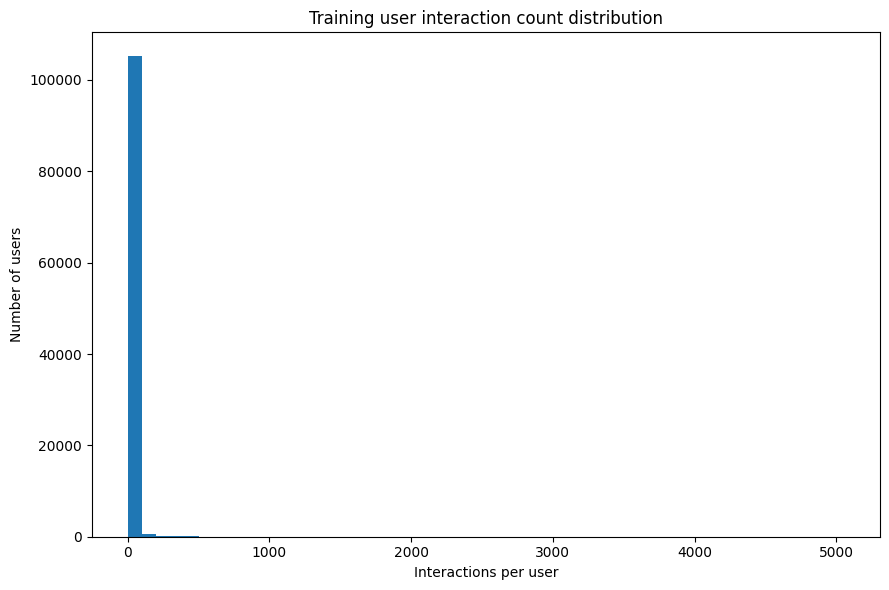

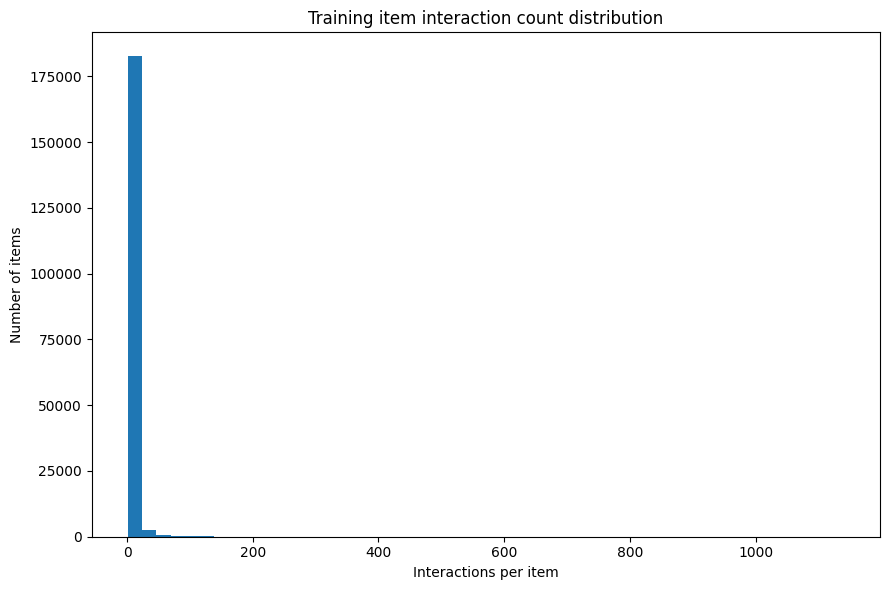

In [14]:
plt.figure(figsize=(9, 6))
plt.hist(user_interaction_counts, bins=50)
plt.xlabel("Interactions per user")
plt.ylabel("Number of users")
plt.title("Training user interaction count distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
plt.hist(item_interaction_counts, bins=50)
plt.xlabel("Interactions per item")
plt.ylabel("Number of items")
plt.title("Training item interaction count distribution")
plt.tight_layout()
plt.show()

## 10. Initialise BPR parameters

User and item latent vectors are initialised randomly with small values.
An item bias term is also used.

In [15]:
rng = np.random.default_rng(RANDOM_STATE)
random.seed(RANDOM_STATE)

user_factors = rng.normal(0, 0.01, size=(n_users, N_FACTORS)).astype(np.float32)
item_factors = rng.normal(0, 0.01, size=(n_items, N_FACTORS)).astype(np.float32)
item_bias = np.zeros(n_items, dtype=np.float32)

all_item_indices = np.arange(n_items, dtype=np.int32)

print("User factors shape:", user_factors.shape)
print("Item factors shape:", item_factors.shape)
print("Item bias shape:", item_bias.shape)

User factors shape: (106304, 64)
Item factors shape: (186564, 64)
Item bias shape: (186564,)


## 11. Define BPR training helpers

BPR samples triplets of the form `(user, positive_item, negative_item)`.

For each step:
- choose a user with at least one observed item
- sample one observed positive item
- sample one unobserved negative item
- update latent factors using the pairwise ranking loss

In [16]:
eligible_user_indices = np.array(
    [u for u, pos_items in user_pos_items_idx.items() if len(pos_items) > 0],
    dtype=np.int32,
)

print("Eligible users for BPR sampling:", len(eligible_user_indices))

Eligible users for BPR sampling: 106304


In [17]:
def sample_bpr_triplet() -> tuple[int, int, int]:
    user_idx = int(rng.choice(eligible_user_indices))
    pos_item_idx = int(rng.choice(list(user_pos_items_idx[user_idx])))

    user_seen = user_pos_items_idx[user_idx]
    neg_item_idx = int(rng.integers(0, n_items))
    while neg_item_idx in user_seen:
        neg_item_idx = int(rng.integers(0, n_items))

    return user_idx, pos_item_idx, neg_item_idx

In [18]:
def sigmoid(x: float) -> float:
    if x >= 0:
        z = math.exp(-x)
        return 1.0 / (1.0 + z)
    z = math.exp(x)
    return z / (1.0 + z)

In [19]:
def bpr_update(
    user_idx: int,
    pos_item_idx: int,
    neg_item_idx: int,
    learning_rate: float,
    regularization: float,
) -> float:
    u = user_factors[user_idx]
    i = item_factors[pos_item_idx]
    j = item_factors[neg_item_idx]

    x_uij = item_bias[pos_item_idx] - item_bias[neg_item_idx] + np.dot(u, i - j)
    s = sigmoid(-x_uij)

    u_old = u.copy()
    i_old = i.copy()
    j_old = j.copy()

    user_factors[user_idx] += learning_rate * (
        s * (i_old - j_old) - regularization * u_old
    )
    item_factors[pos_item_idx] += learning_rate * (
        s * u_old - regularization * i_old
    )
    item_factors[neg_item_idx] += learning_rate * (
        -s * u_old - regularization * j_old
    )

    item_bias[pos_item_idx] += learning_rate * (s - regularization * item_bias[pos_item_idx])
    item_bias[neg_item_idx] += learning_rate * (-s - regularization * item_bias[neg_item_idx])

    return float(math.log(sigmoid(x_uij) + 1e-12))

## 12. Train the BPR model

Training is performed only on the train split using stochastic pairwise updates.
A compact epoch log is retained for inspection.

In [20]:
epoch_rows = []

for epoch in range(1, N_EPOCHS + 1):
    losses = []

    for _ in range(N_SAMPLES_PER_EPOCH):
        u_idx, i_idx, j_idx = sample_bpr_triplet()
        loss_value = bpr_update(
            user_idx=u_idx,
            pos_item_idx=i_idx,
            neg_item_idx=j_idx,
            learning_rate=LEARNING_RATE,
            regularization=REGULARIZATION,
        )
        losses.append(loss_value)

    epoch_rows.append(
        {
            "epoch": epoch,
            "samples": int(N_SAMPLES_PER_EPOCH),
            "mean_log_sigmoid_x_uij": float(np.mean(losses)),
        }
    )

    print(
        f"Epoch {epoch}/{N_EPOCHS} | "
        f"mean_log_sigmoid_x_uij={np.mean(losses):.6f}"
    )

bpr_training_history = pd.DataFrame(epoch_rows)
bpr_training_history

Epoch 1/10 | mean_log_sigmoid_x_uij=-0.611002
Epoch 2/10 | mean_log_sigmoid_x_uij=-0.532040
Epoch 3/10 | mean_log_sigmoid_x_uij=-0.488220
Epoch 4/10 | mean_log_sigmoid_x_uij=-0.458529
Epoch 5/10 | mean_log_sigmoid_x_uij=-0.433786
Epoch 6/10 | mean_log_sigmoid_x_uij=-0.415914
Epoch 7/10 | mean_log_sigmoid_x_uij=-0.399446
Epoch 8/10 | mean_log_sigmoid_x_uij=-0.385521
Epoch 9/10 | mean_log_sigmoid_x_uij=-0.375537
Epoch 10/10 | mean_log_sigmoid_x_uij=-0.364247


,epoch,samples,mean_log_sigmoid_x_uij
0,1,300000,-0.611002
1,2,300000,-0.532040
2,3,300000,-0.488220
3,4,300000,-0.458529
4,5,300000,-0.433786
5,6,300000,-0.415914
6,7,300000,-0.399446
7,8,300000,-0.385521
8,9,300000,-0.375537
9,10,300000,-0.364247


## 13. Save compact training diagnostics

This provides a simple view of whether optimisation is becoming more stable across epochs.

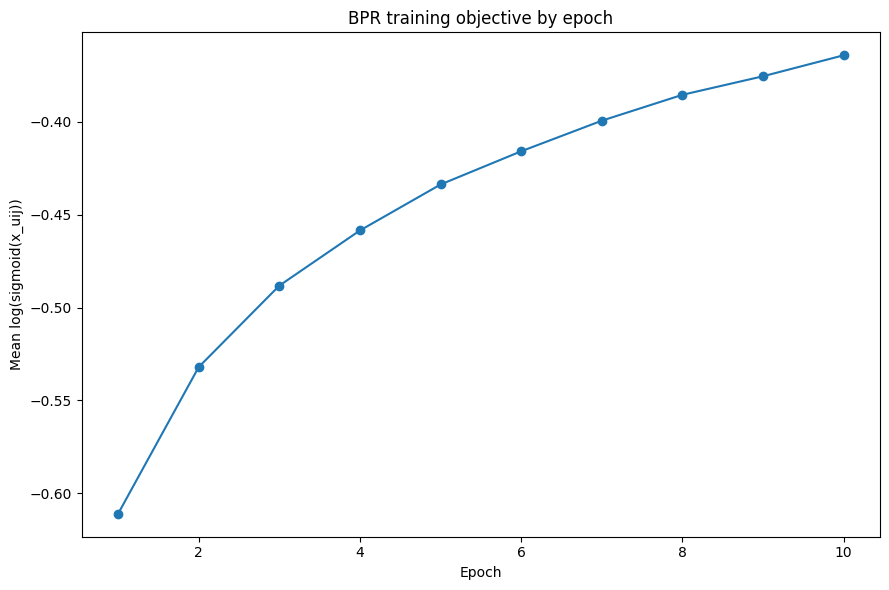

In [21]:
plt.figure(figsize=(9, 6))
plt.plot(
    bpr_training_history["epoch"],
    bpr_training_history["mean_log_sigmoid_x_uij"],
    marker="o",
)
plt.xlabel("Epoch")
plt.ylabel("Mean log(sigmoid(x_uij))")
plt.title("BPR training objective by epoch")
plt.tight_layout()
plt.show()

## 14. Define recommendation helper

For each mapped user:
- score all mapped items using learned BPR latent factors
- remove items already seen in training
- return the highest-ranked unseen items

In [22]:
def recommend_bpr(user_id: int, top_n: int = 10) -> list[tuple[int, float]]:
    if user_id not in user_id_to_user_idx:
        return []

    user_idx = int(user_id_to_user_idx[user_id])
    seen_recipe_ids = user_seen_train.get(user_id, set())
    seen_item_indices = user_pos_items_idx.get(user_idx, set())

    scores = item_bias + item_factors @ user_factors[user_idx]

    if len(seen_item_indices) > 0:
        seen_item_indices_array = np.array(list(seen_item_indices), dtype=np.int32)
        scores[seen_item_indices_array] = -np.inf

    candidate_count = min(max(top_n * 20, 100), n_items)
    top_positions = np.argpartition(-scores, candidate_count - 1)[:candidate_count]
    top_positions = top_positions[np.argsort(-scores[top_positions])]

    recs = []
    for item_idx in top_positions:
        recipe_id = int(item_idx_to_recipe_id[int(item_idx)])
        if recipe_id in seen_recipe_ids:
            continue
        recs.append((recipe_id, float(scores[item_idx])))
        if len(recs) == top_n:
            break

    return recs

## 15. Quick recommendation sanity check

In [23]:
example_user_ids = list(valid_truth.keys())[:5]

for user_id in example_user_ids:
    recs = recommend_bpr(user_id=user_id, top_n=5)
    print(f"User {user_id}: {recs[:5]}")

User 1535: [(39087, 4.4689435958862305), (22782, 4.438194274902344), (67256, 4.426150798797607), (89204, 4.4026079177856445), (73166, 4.34469747543335)]
User 1634: [(39087, 4.46946382522583), (22782, 4.439301490783691), (67256, 4.426206111907959), (89204, 4.402804851531982), (27208, 4.398994445800781)]
User 1891: [(39087, 4.468996047973633), (67256, 4.426351070404053), (89204, 4.403698444366455), (27208, 4.398697376251221), (73166, 4.344949722290039)]
User 2586: [(39087, 4.470569610595703), (22782, 4.439225673675537), (67256, 4.425762176513672), (89204, 4.403710842132568), (27208, 4.398387432098389)]
User 2695: [(39087, 4.469948768615723), (22782, 4.439036846160889), (67256, 4.426496505737305), (89204, 4.403497695922852), (27208, 4.3986735343933105)]


## 16. Define evaluation helpers

The same Top-N metrics used in earlier recommender notebooks are used here for comparability.

In [24]:
def precision_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if k <= 0:
        return 0.0
    hits = sum(1 for item in recommended[:k] if item in relevant)
    return hits / k

def recall_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return 0.0
    hits = sum(1 for item in recommended[:k] if item in relevant)
    return hits / len(relevant)

def hit_rate_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    return 1.0 if any(item in relevant for item in recommended[:k]) else 0.0

def dcg_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    dcg = 0.0
    for rank, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            dcg += 1.0 / math.log2(rank + 1)
    return dcg

def ndcg_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return 0.0
    idcg = sum(1.0 / math.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    return dcg_at_k(recommended, relevant, k) / idcg if idcg > 0 else 0.0

## 17. Define novelty and coverage helpers

In [25]:
item_popularity_train = (
    train_bpr.groupby("recipe_id", as_index=False)
    .agg(train_interaction_count=("implicit_feedback", "sum"))
)

total_train_interactions = float(item_popularity_train["train_interaction_count"].sum())

recipe_popularity_prob = (
    item_popularity_train.set_index("recipe_id")["train_interaction_count"] / total_train_interactions
).to_dict()

all_train_recipe_ids = set(train_bpr["recipe_id"].unique())

def novelty_at_k(recommended: list[int], k: int) -> float:
    vals = []
    for recipe_id in recommended[:k]:
        p = recipe_popularity_prob.get(recipe_id, 1 / total_train_interactions)
        vals.append(-math.log2(p))
    return float(np.mean(vals)) if vals else 0.0

def catalogue_coverage(recommendation_lists: list[list[int]]) -> float:
    recommended_unique = set()
    for recs in recommendation_lists:
        recommended_unique.update(recs)
    if not all_train_recipe_ids:
        return 0.0
    return len(recommended_unique) / len(all_train_recipe_ids)

## 18. Evaluate a split

In [26]:
def evaluate_split(
    truth_dict: dict[int, set[int]],
    split_name: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    recommendation_export_rows = []

    users_evaluated = 0
    all_recommendation_lists = []

    for user_id, relevant_items in truth_dict.items():
        recs_with_scores = recommend_bpr(user_id=user_id, top_n=max(TOP_K_VALUES))
        recommended_items = [recipe_id for recipe_id, _ in recs_with_scores]

        if len(recommended_items) == 0:
            continue

        users_evaluated += 1
        all_recommendation_lists.append(recommended_items[:EXPORT_TOP_N])

        for rank_position, (recipe_id, score) in enumerate(recs_with_scores[:EXPORT_TOP_N], start=1):
            recommendation_export_rows.append(
                {
                    "split": split_name,
                    "user_id": int(user_id),
                    "rank": rank_position,
                    "recipe_id": int(recipe_id),
                    "score": float(score),
                }
            )

    for k in TOP_K_VALUES:
        precision_values = []
        recall_values = []
        hit_rate_values = []
        ndcg_values = []
        novelty_values = []

        for user_id, relevant_items in truth_dict.items():
            recs_with_scores = recommend_bpr(user_id=user_id, top_n=k)
            recommended_items = [recipe_id for recipe_id, _ in recs_with_scores]

            if len(recommended_items) == 0:
                continue

            precision_values.append(precision_at_k(recommended_items, relevant_items, k))
            recall_values.append(recall_at_k(recommended_items, relevant_items, k))
            hit_rate_values.append(hit_rate_at_k(recommended_items, relevant_items, k))
            ndcg_values.append(ndcg_at_k(recommended_items, relevant_items, k))
            novelty_values.append(novelty_at_k(recommended_items, k))

        rows.append(
            {
                "split": split_name,
                "k": k,
                "users_in_truth": int(len(truth_dict)),
                "users_evaluated": int(users_evaluated),
                "precision_at_k": float(np.mean(precision_values)) if precision_values else 0.0,
                "recall_at_k": float(np.mean(recall_values)) if recall_values else 0.0,
                "hit_rate_at_k": float(np.mean(hit_rate_values)) if hit_rate_values else 0.0,
                "ndcg_at_k": float(np.mean(ndcg_values)) if ndcg_values else 0.0,
                "novelty_at_k": float(np.mean(novelty_values)) if novelty_values else 0.0,
                "coverage": float(catalogue_coverage(all_recommendation_lists)),
            }
        )

    metrics_df = pd.DataFrame(rows)
    recommendations_df = pd.DataFrame(recommendation_export_rows)

    return metrics_df, recommendations_df

## 19. Run validation and test evaluation

In [27]:
valid_metrics, valid_recommendations = evaluate_split(
    truth_dict=valid_truth,
    split_name="valid",
)

test_metrics, test_recommendations = evaluate_split(
    truth_dict=test_truth,
    split_name="test",
)

bpr_metrics = pd.concat([valid_metrics, test_metrics], ignore_index=True)

display(bpr_metrics)
display(valid_recommendations.head(10))
display(test_recommendations.head(10))

,split,k,users_in_truth,users_evaluated,precision_at_k,recall_at_k,hit_rate_at_k,ndcg_at_k,novelty_at_k,coverage
0,valid,5,12779,12779,0.009390,0.014793,0.043744,0.013236,9.786581,0.000172
1,valid,10,12779,12779,0.007348,0.021621,0.065968,0.015127,10.413068,0.000172
2,valid,20,12779,12779,0.006472,0.036734,0.106816,0.019575,10.607798,0.000172
3,test,5,6048,6048,0.006349,0.011746,0.030589,0.010395,9.794313,0.000172
4,test,10,6048,6048,0.005308,0.018447,0.048776,0.012556,10.419283,0.000172
5,test,20,6048,6048,0.005159,0.033718,0.086475,0.017008,10.610336,0.000172


,split,user_id,rank,recipe_id,score
0,valid,1535,1,39087,4.468944
1,valid,1535,2,22782,4.438194
2,valid,1535,3,67256,4.426151
3,valid,1535,4,89204,4.402608
4,valid,1535,5,73166,4.344697
5,valid,1535,6,54257,4.338822
6,valid,1535,7,141983,4.299387
7,valid,1535,8,4627,4.271489
8,valid,1535,9,66121,4.257300
9,valid,1535,10,15865,4.252213


,split,user_id,rank,recipe_id,score
0,test,1535,1,39087,4.468944
1,test,1535,2,22782,4.438194
2,test,1535,3,67256,4.426151
3,test,1535,4,89204,4.402608
4,test,1535,5,73166,4.344697
5,test,1535,6,54257,4.338822
6,test,1535,7,141983,4.299387
7,test,1535,8,4627,4.271489
8,test,1535,9,66121,4.257300
9,test,1535,10,15865,4.252213


## 20. Inspect recommendation popularity concentration

This helps show whether BPR still concentrates strongly on a small subset of items.

In [28]:
def summarise_recommendation_popularity(
    recommendations_df: pd.DataFrame,
    split_name: str,
) -> pd.DataFrame:
    summary = (
        recommendations_df.groupby("recipe_id", as_index=False)
        .agg(recommendation_count=("user_id", "count"))
        .sort_values("recommendation_count", ascending=False)
        .reset_index(drop=True)
    )
    summary["split"] = split_name
    summary["recommendation_rank"] = np.arange(1, len(summary) + 1)
    summary["recommendation_share"] = (
        summary["recommendation_count"] / summary["recommendation_count"].sum()
    )
    summary["cumulative_recommendation_share"] = summary["recommendation_share"].cumsum()
    summary["cumulative_item_share"] = np.arange(1, len(summary) + 1) / len(summary)
    return summary

valid_recommendation_popularity = summarise_recommendation_popularity(
    valid_recommendations,
    split_name="valid",
)

test_recommendation_popularity = summarise_recommendation_popularity(
    test_recommendations,
    split_name="test",
)

display(valid_recommendation_popularity.head(10))
display(test_recommendation_popularity.head(10))

,recipe_id,recommendation_count,split,recommendation_rank,recommendation_share,cumulative_recommendation_share,cumulative_item_share
0,141983,12686,valid,1,0.099272,0.099272,0.03125
1,66121,12646,valid,2,0.098959,0.198231,0.06250
2,73166,12634,valid,3,0.098865,0.297097,0.09375
3,4627,12580,valid,4,0.098443,0.395540,0.12500
4,67256,12486,valid,5,0.097707,0.493247,0.15625
5,54257,12464,valid,6,0.097535,0.590782,0.18750
6,22782,12422,valid,7,0.097206,0.687988,0.21875
7,39087,12374,valid,8,0.096831,0.784819,0.25000
8,89204,12296,valid,9,0.096220,0.881039,0.28125
9,27208,12292,valid,10,0.096189,0.977228,0.31250


,recipe_id,recommendation_count,split,recommendation_rank,recommendation_share,cumulative_recommendation_share,cumulative_item_share
0,141983,6001,test,1,0.099223,0.099223,0.03125
1,66121,5970,test,2,0.098710,0.197933,0.06250
2,73166,5963,test,3,0.098595,0.296528,0.09375
3,4627,5942,test,4,0.098247,0.394775,0.12500
4,54257,5883,test,5,0.097272,0.492047,0.15625
5,67256,5859,test,6,0.096875,0.588922,0.18750
6,39087,5842,test,7,0.096594,0.685516,0.21875
7,22782,5833,test,8,0.096445,0.781961,0.25000
8,89204,5779,test,9,0.095552,0.877513,0.28125
9,27208,5758,test,10,0.095205,0.972718,0.31250


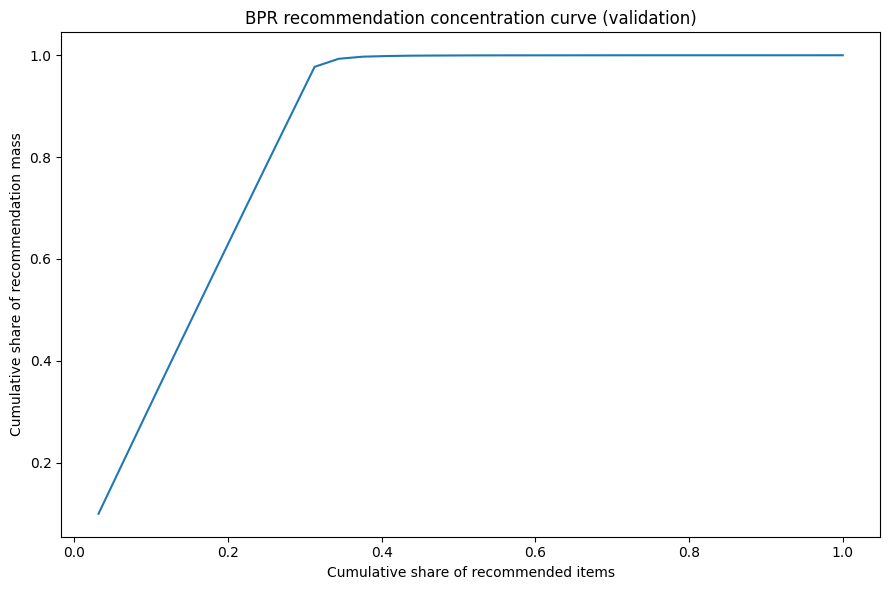

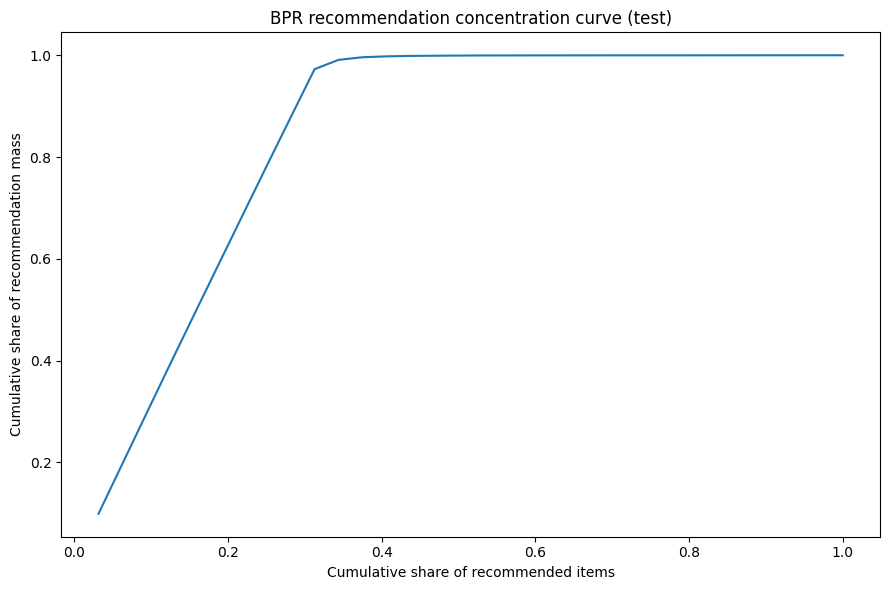

In [29]:
plt.figure(figsize=(9, 6))
plt.plot(
    valid_recommendation_popularity["cumulative_item_share"],
    valid_recommendation_popularity["cumulative_recommendation_share"],
)
plt.xlabel("Cumulative share of recommended items")
plt.ylabel("Cumulative share of recommendation mass")
plt.title("BPR recommendation concentration curve (validation)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
plt.plot(
    test_recommendation_popularity["cumulative_item_share"],
    test_recommendation_popularity["cumulative_recommendation_share"],
)
plt.xlabel("Cumulative share of recommended items")
plt.ylabel("Cumulative share of recommendation mass")
plt.title("BPR recommendation concentration curve (test)")
plt.tight_layout()
plt.show()

## 21. Build compact model summary

In [30]:
bpr_model_summary = pd.DataFrame(
    [
        {
            "n_users": int(n_users),
            "n_items": int(n_items),
            "n_factors": int(N_FACTORS),
            "learning_rate": float(LEARNING_RATE),
            "regularization": float(REGULARIZATION),
            "n_epochs": int(N_EPOCHS),
            "n_samples_per_epoch": int(N_SAMPLES_PER_EPOCH),
            "train_nnz": int(train_matrix.nnz),
            "train_density": float(train_matrix.nnz / (train_matrix.shape[0] * train_matrix.shape[1])),
        }
    ]
)

bpr_model_summary

,n_users,n_items,n_factors,learning_rate,regularization,n_epochs,n_samples_per_epoch,train_nnz,train_density
0,106304,186564,64,0.05,0.0025,10,300000,792656,0.00004


In [31]:
coverage_summary.to_csv(TABLES_SUBDIR / "11_bpr_mapping_coverage_summary.csv", index=False)
bpr_split_summary.to_csv(TABLES_SUBDIR / "11_bpr_split_summary.csv", index=False)
bpr_training_history.to_csv(TABLES_SUBDIR / "11_bpr_training_history.csv", index=False)
bpr_metrics.to_csv(TABLES_SUBDIR / "11_bpr_metrics.csv", index=False)
bpr_model_summary.to_csv(TABLES_SUBDIR / "11_bpr_model_summary.csv", index=False)

valid_recommendations.to_csv(TABLES_SUBDIR / "11_bpr_valid_recommendations.csv", index=False)
test_recommendations.to_csv(TABLES_SUBDIR / "11_bpr_test_recommendations.csv", index=False)

valid_recommendation_popularity.to_csv(
    TABLES_SUBDIR / "11_bpr_valid_recommendation_popularity.csv",
    index=False,
)
test_recommendation_popularity.to_csv(
    TABLES_SUBDIR / "11_bpr_test_recommendation_popularity.csv",
    index=False,
)

print("BPR tables saved.")

BPR tables saved.


## 23. Save figures

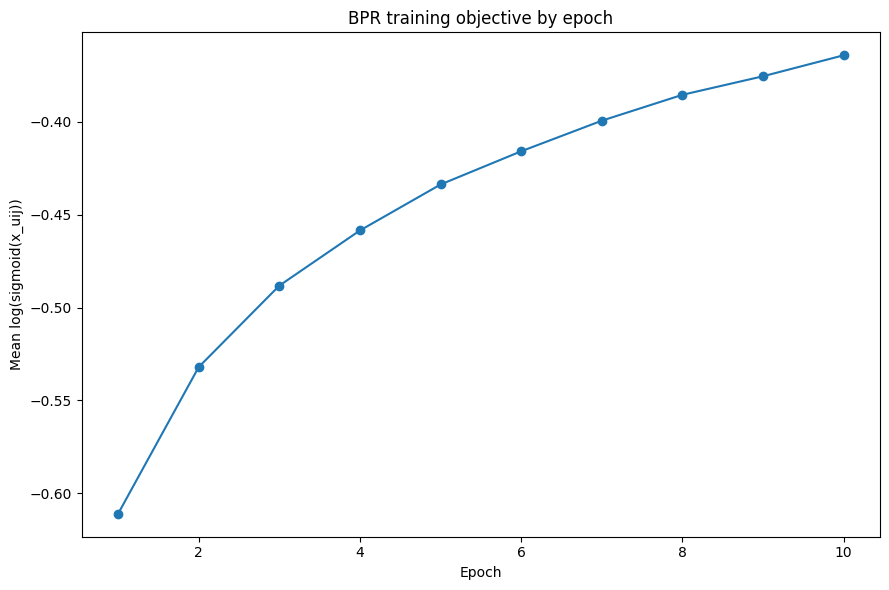

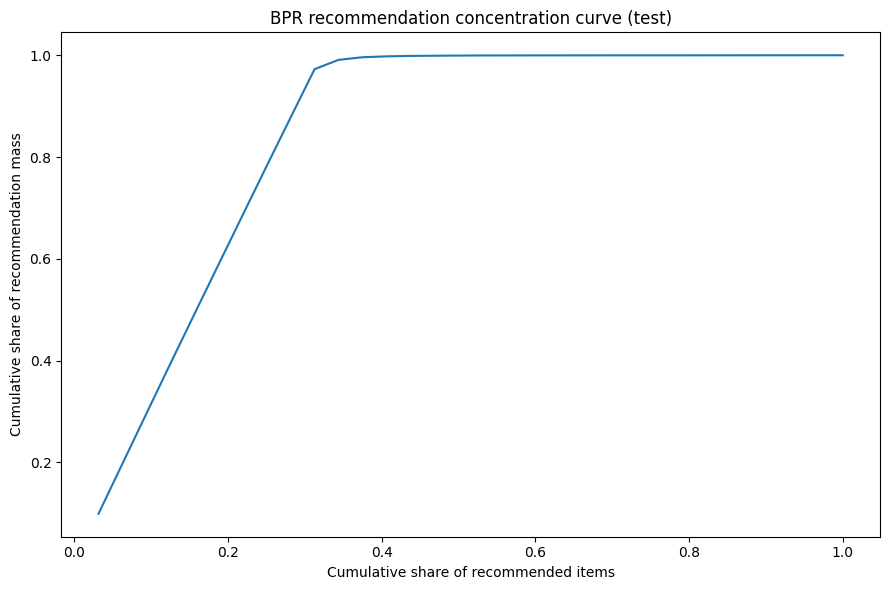

BPR figures saved.


In [32]:
plt.figure(figsize=(9, 6))
plt.plot(
    bpr_training_history["epoch"],
    bpr_training_history["mean_log_sigmoid_x_uij"],
    marker="o",
)
plt.xlabel("Epoch")
plt.ylabel("Mean log(sigmoid(x_uij))")
plt.title("BPR training objective by epoch")
plt.tight_layout()
plt.savefig(FIGURES_SUBDIR / "11_bpr_training_curve.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 6))
plt.plot(
    test_recommendation_popularity["cumulative_item_share"],
    test_recommendation_popularity["cumulative_recommendation_share"],
)
plt.xlabel("Cumulative share of recommended items")
plt.ylabel("Cumulative share of recommendation mass")
plt.title("BPR recommendation concentration curve (test)")
plt.tight_layout()
plt.savefig(FIGURES_SUBDIR / "11_bpr_recommendation_concentration_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print("BPR figures saved.")

## 24. Save learned parameters

This allows later reuse in scripts or dashboard experiments.

In [33]:
np.save(MODELS_SUBDIR / "11_bpr_user_factors.npy", user_factors)
np.save(MODELS_SUBDIR / "11_bpr_item_factors.npy", item_factors)
np.save(MODELS_SUBDIR / "11_bpr_item_bias.npy", item_bias)

print("BPR model arrays saved.")

BPR model arrays saved.


## 25. Save compact run log

In [34]:
run_log = {
    "model_name": MODEL_NAME,
    "top_k_values": TOP_K_VALUES,
    "export_top_n": EXPORT_TOP_N,
    "n_factors": N_FACTORS,
    "learning_rate": LEARNING_RATE,
    "regularization": REGULARIZATION,
    "n_epochs": N_EPOCHS,
    "n_samples_per_epoch": N_SAMPLES_PER_EPOCH,
    "random_state": RANDOM_STATE,
    "train_rows": int(len(train_bpr)),
    "valid_rows": int(len(valid_bpr)),
    "test_rows": int(len(test_bpr)),
    "n_users": int(n_users),
    "n_items": int(n_items),
    "train_nnz": int(train_matrix.nnz),
    "valid_users_in_truth": int(len(valid_truth)),
    "test_users_in_truth": int(len(test_truth)),
}

with open(LOGS_SUBDIR / "11_bpr_run_log.json", "w", encoding="utf-8") as f:
    json.dump(run_log, f, indent=2)

print("BPR run log saved.")

BPR run log saved.


## 26. Summary

This notebook implemented a Bayesian Personalised Ranking recommender on the chronological implicit interaction data.

Key modelling decisions in this phase:

- the model was trained only on the implicit training split
- train-fitted user and item mappings were reused from Phase 5
- only mapped user–item rows were included in BPR evaluation
- observed train interactions were treated as positive implicit feedback
- pairwise ranking updates were used instead of rating prediction
- recommendations excluded recipes already seen in training
- validation and test performance were evaluated with Top-N ranking metrics
- novelty, coverage, and recommendation concentration were analysed alongside accuracy

These outputs are now ready for:

- comparison against popularity, CF, SVD, and hybrid models
- dashboard integration
- later pipeline refactoring into `src/models/train_bpr.py`